In [44]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [45]:
df = pd.read_csv("loan_approval_data (1).csv")

In [46]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [47]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df = df.drop("Applicant_ID",axis = 1)

In [50]:
df.dtypes

Applicant_Income      float64
Coapplicant_Income    float64
Employment_Status      object
Age                   float64
Marital_Status         object
Dependents            float64
Credit_Score          float64
Existing_Loans        float64
DTI_Ratio             float64
Savings               float64
Collateral_Value      float64
Loan_Amount           float64
Loan_Term             float64
Loan_Purpose           object
Property_Area          object
Education_Level        object
Gender                 object
Employer_Category      object
Loan_Approved          object
dtype: object

In [51]:
numerical_cols = df.select_dtypes(include = "number").columns
categorical_cols = df.select_dtypes(include = "object").columns

In [52]:
numerical_cols

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [53]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [54]:
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

In [55]:
df.isnull().sum()

Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [56]:
from sklearn.impute import SimpleImputer

In [57]:
im = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = im.fit_transform(df[categorical_cols])

In [58]:
df.isnull().sum()

Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [59]:
df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [60]:
df["Loan_Approved"].value_counts()

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

#  EDA

Text(0.5, 1.0, 'loan_approved or not')

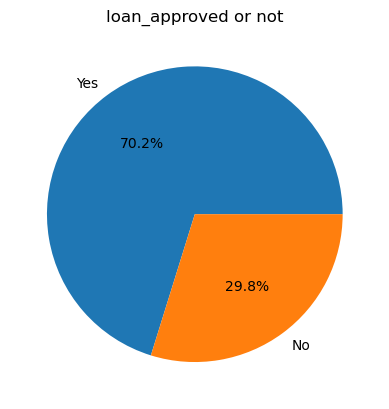

In [61]:
classes = df["Loan_Approved"].value_counts()
plt.pie(classes,labels = ["Yes","No"],autopct = "%1.1f%%")
plt.title("loan_approved or not")

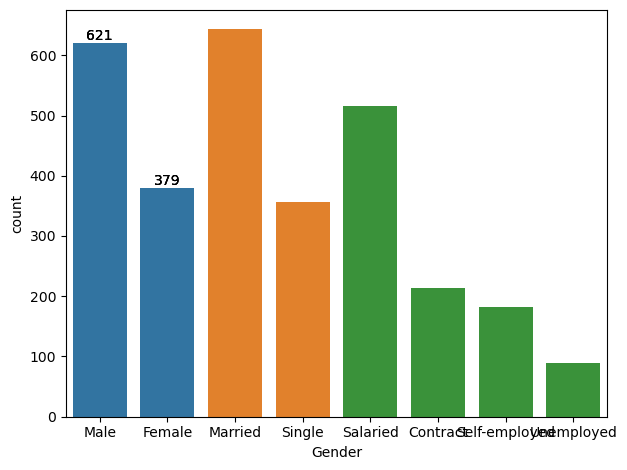

In [62]:
# analyse catoagories values

gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

mar_cnt = df["Marital_Status"].value_counts()
ax = sns.barplot(mar_cnt)
ax.bar_label(ax.containers[0])

emp_cnt = df["Employment_Status"].value_counts()
ax = sns.barplot(emp_cnt)
ax.bar_label(ax.containers[0])

plt.tight_layout()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

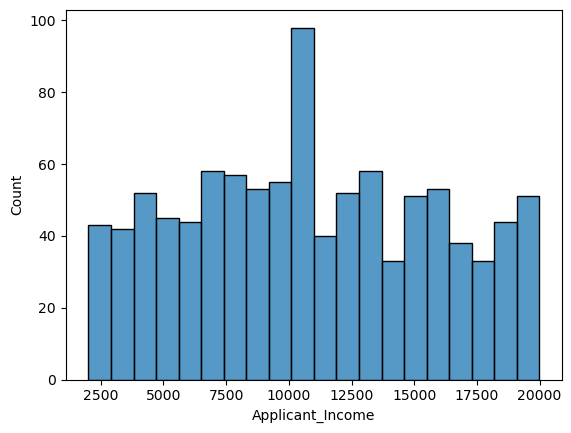

In [63]:
sns.histplot(data = df,x = "Applicant_Income",bins = 20)

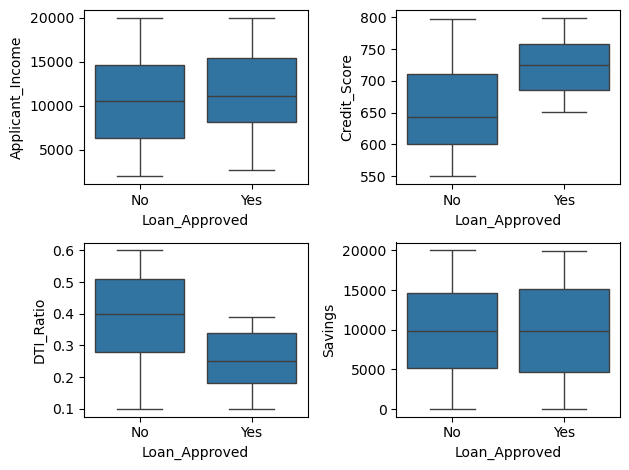

In [64]:
fig,axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0],data = df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1],data = df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0],data = df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1],data = df,x = "Loan_Approved",y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

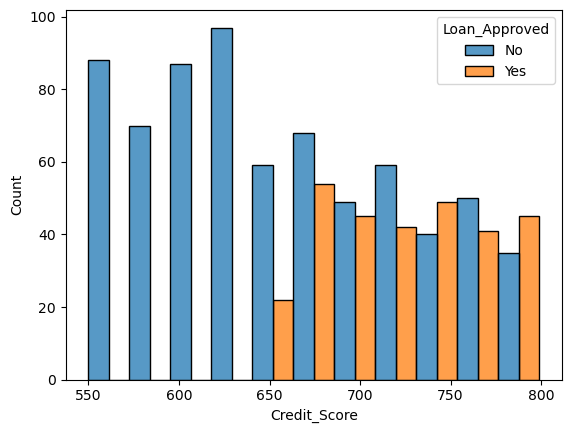

In [65]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    multiple = "dodge"
    
)

In [66]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [67]:
df["Employment_Status"].value_counts()

Employment_Status
Salaried         515
Contract         213
Self-employed    182
Unemployed        90
Name: count, dtype: int64

In [68]:
from sklearn.preprocessing import LabelEncoder

In [69]:
col = ["Loan_Approved","Gender","Education_Level","Marital_Status"]

In [70]:
le = LabelEncoder()

In [71]:
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
df["Gender"] = le.fit_transform(df["Gender"])
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Marital_Status"] = le.fit_transform(df["Marital_Status"])

In [72]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,0,Private,0
1,2860.0,2679.0,Salaried,46.0,0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,1,Private,0
2,7390.0,2106.0,Salaried,25.0,1,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,0,Government,1
3,13964.0,8173.0,Salaried,40.0,0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,0,Government,0
4,13284.0,4223.0,Self-employed,31.0,1,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,1,Private,1


In [73]:
one = OneHotEncoder(drop="first",sparse_output = False,handle_unknown = "ignore")

In [74]:
cols = ["Employer_Category","Property_Area","Loan_Purpose","Employment_Status"]

In [75]:
encoded = one.fit_transform(df[cols])

In [76]:
encoded_df = pd.DataFrame(encoded,columns = one.get_feature_names_out(cols),index = df.index)

In [77]:
df = pd.concat([df.drop(columns = cols) ,encoded_df],axis = 1)

In [78]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Employer_Category_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
0,17795.0,1387.0,51.0,0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,1,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,13964.0,8173.0,40.0,0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,13284.0,4223.0,31.0,1,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [79]:
df.shape

(1000, 28)

In [80]:
df2 = df.copy()

In [81]:
num_cols =  df.select_dtypes(include = "number")
corr_metrix = num_cols.corr()

<Axes: >

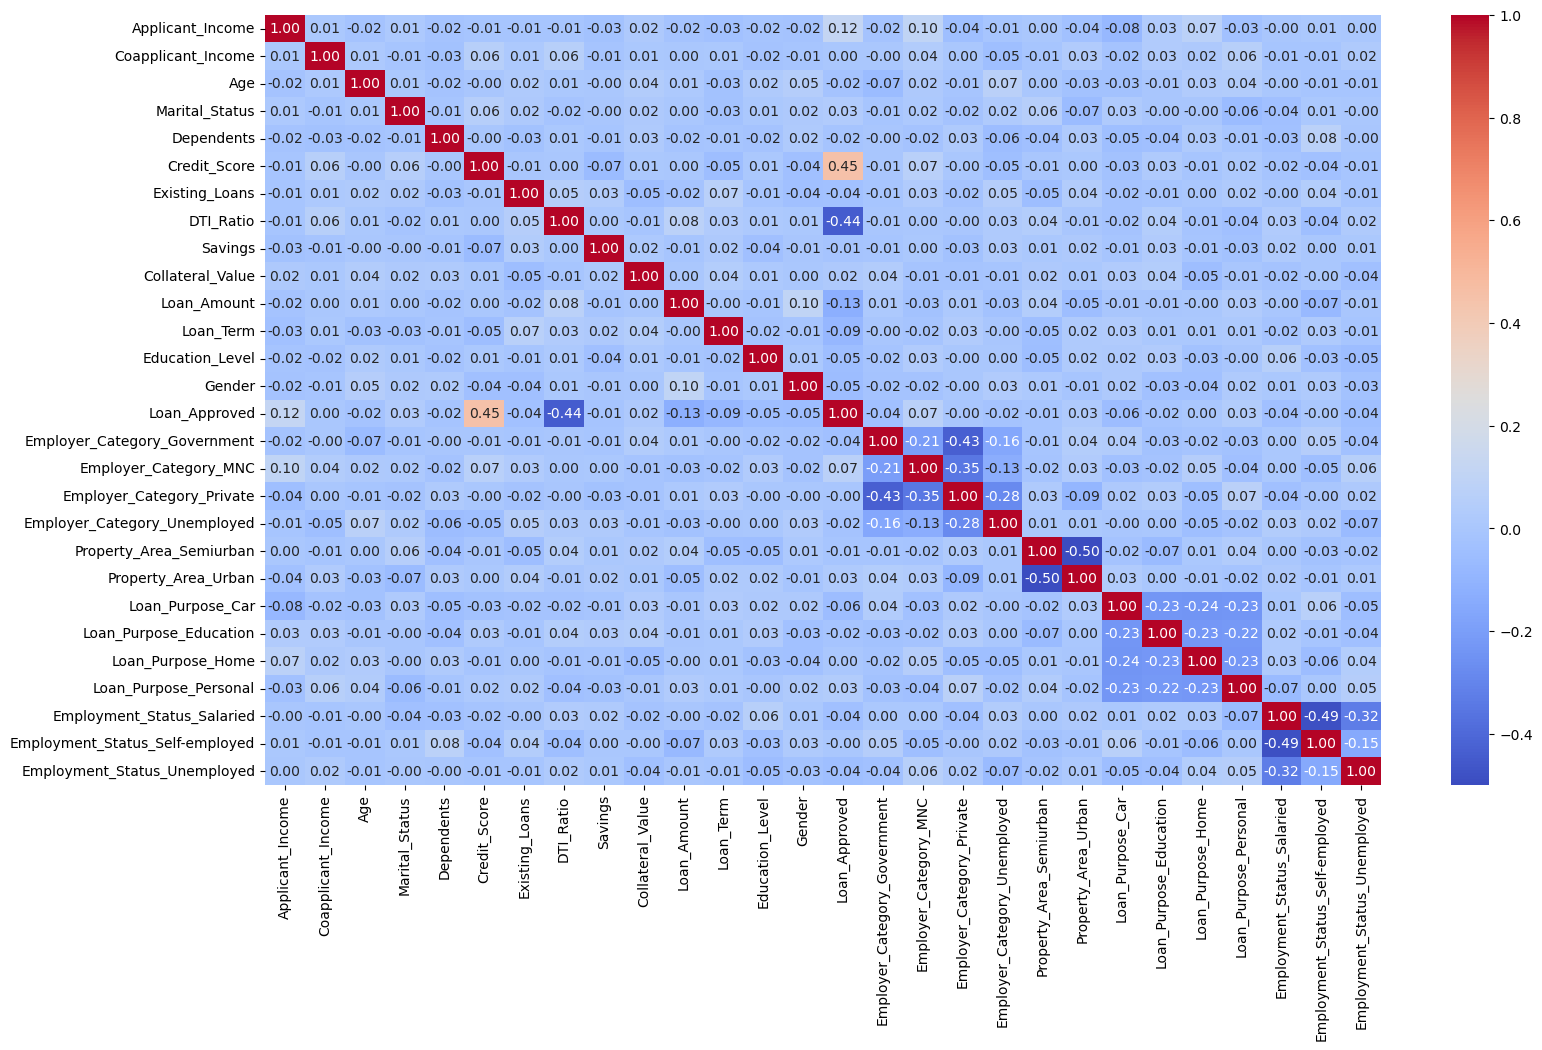

In [82]:
plt.figure(figsize = (18,10))
sns.heatmap(
    corr_metrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [83]:
x = df.drop("Loan_Approved",axis = 1)
y = df["Loan_Approved"]

In [84]:
x.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Marital_Status',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level',
       'Gender', 'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed',
       'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Purpose_Car',
       'Loan_Purpose_Education', 'Loan_Purpose_Home', 'Loan_Purpose_Personal',
       'Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed'],
      dtype='object')

In [85]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42,stratify = y)

In [86]:
from sklearn.preprocessing import StandardScaler

In [87]:
scaler = StandardScaler()

In [88]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [89]:
from sklearn.linear_model import LogisticRegression

# logistic regression

In [90]:
log_model = LogisticRegression(max_iter = 1000)

In [91]:
log_model.fit(x_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [92]:
y_pred = log_model.predict(x_test_scaled)

In [93]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,recall_score,f1_score

In [94]:
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))
print("F1_score: ",f1_score(y_test,y_pred))

accuracy score:  0.805
precisionn score:  0.647887323943662
recall score:  0.7666666666666667
confusion_matrix:  [[115  25]
 [ 14  46]]
F1_score:  0.7022900763358778


#  KNN

In [95]:
from sklearn.neighbors import KNeighborsClassifier

In [96]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(x_train_scaled,y_train)

KNeighborsClassifier()

In [97]:
y_pred = knn_model.predict(x_test_scaled)

In [98]:
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))
print("F1_score: ",f1_score(y_test,y_pred))

accuracy score:  0.745
precisionn score:  0.5737704918032787
recall score:  0.5833333333333334
confusion_matrix:  [[114  26]
 [ 25  35]]
F1_score:  0.5785123966942148


#  naive bayes

In [99]:
from sklearn.naive_bayes import GaussianNB

In [100]:
naive_model = GaussianNB()

In [101]:
naive_model.fit(x_train_scaled,y_train)

GaussianNB()

In [102]:
y_pred = naive_model.predict(x_test_scaled)

In [103]:
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))
print("F1_score: ",f1_score(y_test,y_pred))

accuracy score:  0.8
precisionn score:  0.6666666666666666
recall score:  0.6666666666666666
confusion_matrix:  [[120  20]
 [ 20  40]]
F1_score:  0.6666666666666666


# decision tree

In [104]:
#  decision tree 
from sklearn.tree import DecisionTreeClassifier

In [105]:
for d in range(2,10):
    decision_model = DecisionTreeClassifier(max_depth = d,random_state = 42)
    decision_model.fit(x_train,y_train)
    acc = decision_model.score(x_test,y_test)
    print(f"accuracy: {acc} for max_dpth:{d}")

accuracy: 0.88 for max_dpth:2
accuracy: 0.895 for max_dpth:3
accuracy: 0.905 for max_dpth:4
accuracy: 0.915 for max_dpth:5
accuracy: 0.905 for max_dpth:6
accuracy: 0.905 for max_dpth:7
accuracy: 0.905 for max_dpth:8
accuracy: 0.91 for max_dpth:9


In [106]:
from sklearn.tree import plot_tree

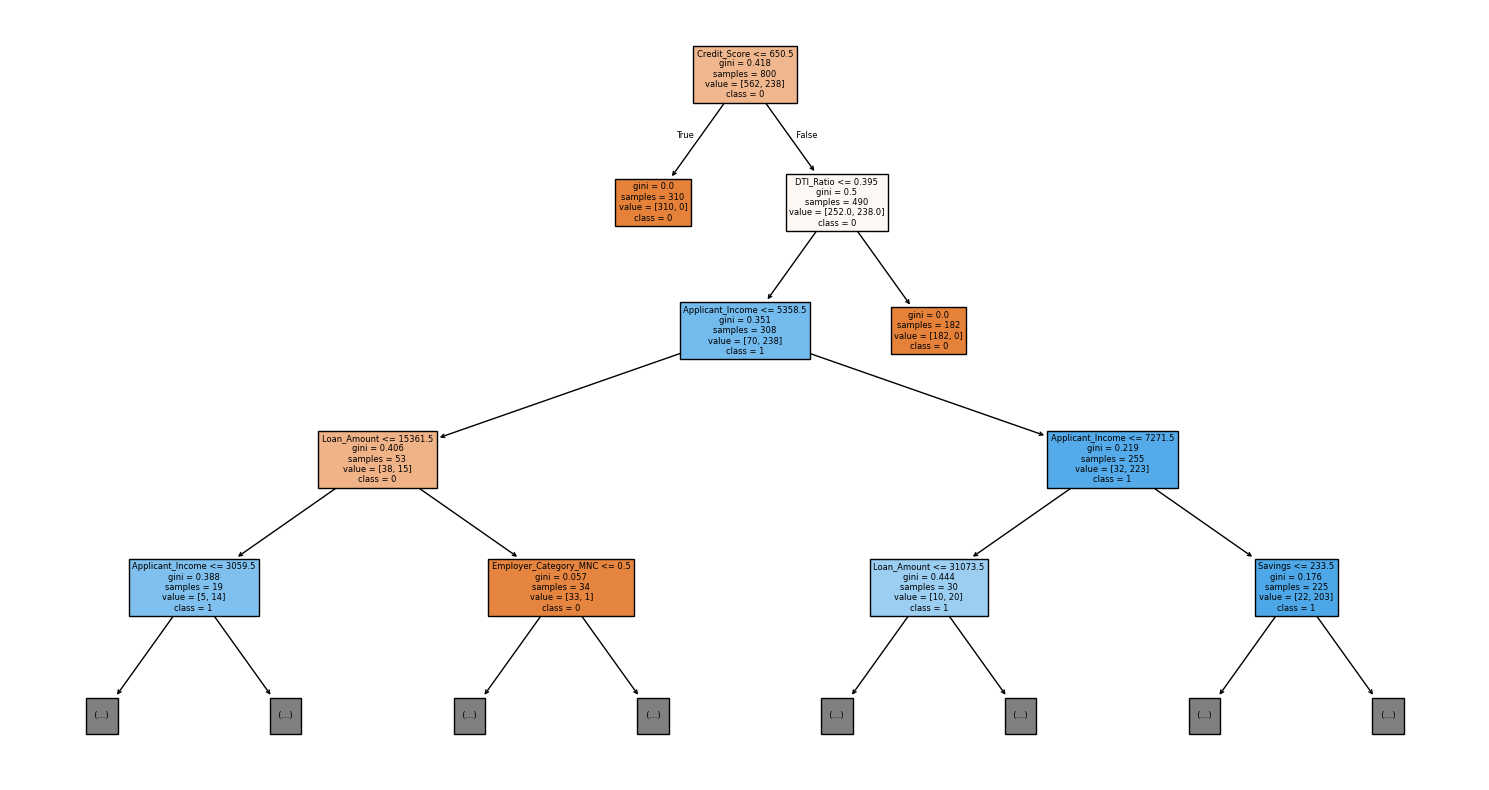

In [107]:
plt.figure(figsize = (15,8))
plot_tree(decision_model,feature_names = x.columns,class_names = ["0","1"],filled = True,max_depth = 4)
plt.tight_layout()
plt.show()

In [108]:
#  by post-purning in decision tree

In [109]:
full_tree = DecisionTreeClassifier(random_state = 42)

In [110]:
full_tree.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [111]:
path = full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alpha = path.ccp_alphas

In [112]:
ccp_alpha

array([0.        , 0.00082569, 0.00119048, 0.00121324, 0.00121344,
       0.00166667, 0.00166667, 0.001875  , 0.00192415, 0.00208333,
       0.00222222, 0.00238095, 0.00241935, 0.0030429 , 0.00410653,
       0.00712719, 0.0089788 , 0.0152498 , 0.0383797 , 0.14138011])

In [113]:
tree = []
for alpha in ccp_alpha:
    model = DecisionTreeClassifier(random_state = 42,ccp_alpha = alpha)
    model.fit(x_train,y_train)
    tree.append((model,alpha))
    

In [114]:
best_acc = 0
best_alpha = 0

for model,alpha in tree:
    curr_acc = model.score(x_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [115]:
best_alpha

np.float64(0.0023809523809523816)

In [116]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha,random_state = 42)
best_model.fit(x_train,y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0023809523809523816),
                       random_state=42)

In [117]:
best_model

DecisionTreeClassifier(ccp_alpha=np.float64(0.0023809523809523816),
                       random_state=42)

In [118]:
best_acc

0.915

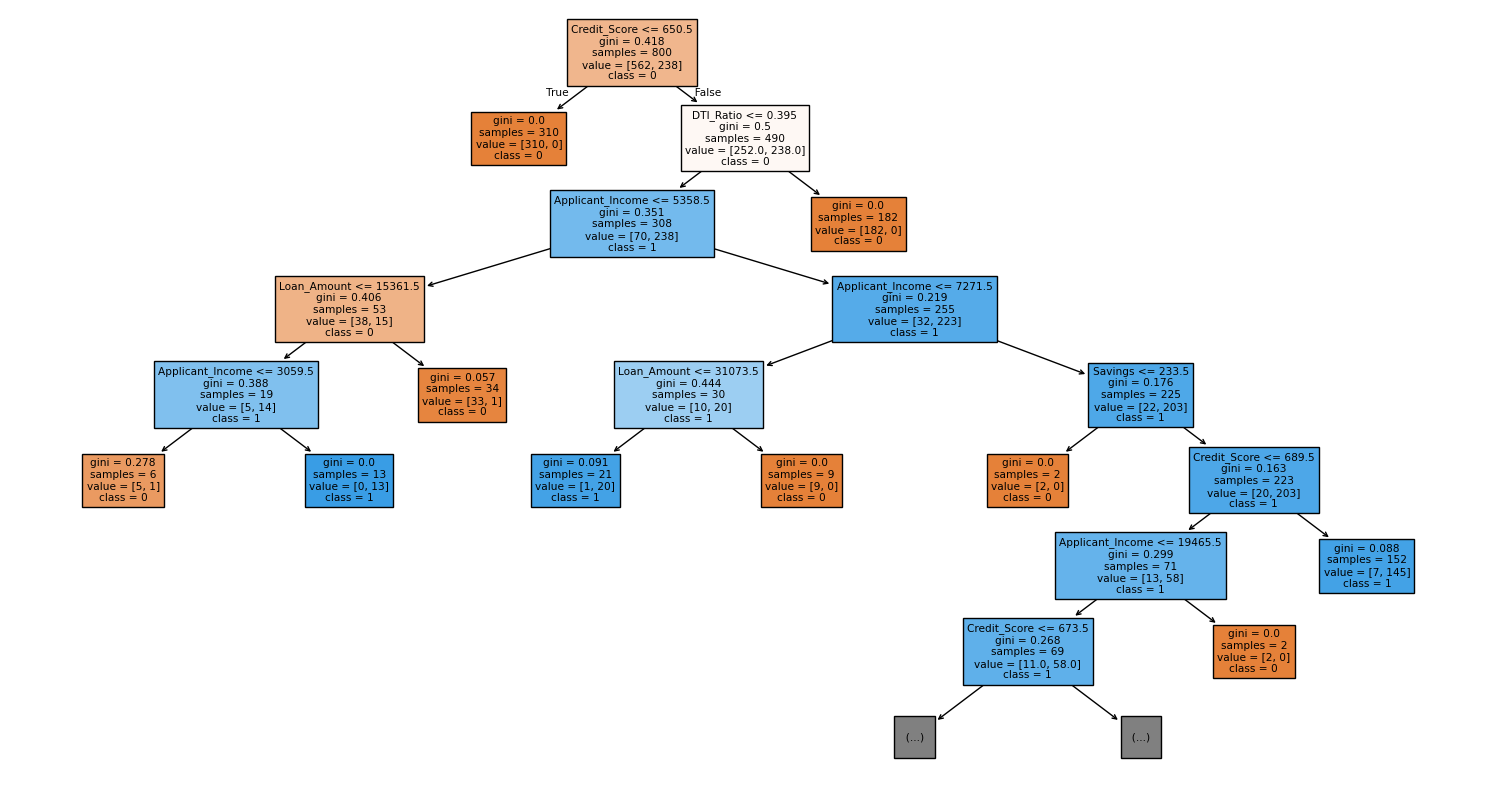

In [119]:
plt.figure(figsize = (15,8))
plot_tree(best_model,feature_names = x.columns,class_names = ["0","1"],filled = True,max_depth = 7)
plt.tight_layout()
plt.show()

# now for random_forest

In [120]:
from sklearn.ensemble import RandomForestClassifier

In [121]:
random_model = RandomForestClassifier(n_estimators = 201,oob_score = True,max_depth = 7)

In [122]:
random_model.fit(x_train,y_train)

RandomForestClassifier(max_depth=7, n_estimators=201, oob_score=True)

In [123]:
y_pred = random_model.predict(x_test)
y_pred_train = random_model.predict(x_train)

In [124]:
print("accuracy score: ",accuracy_score(y_pred,y_test))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))
print("F1_score: ",f1_score(y_test,y_pred))

accuracy score:  0.895
precisionn score:  0.7746478873239436
recall score:  0.9166666666666666
confusion_matrix:  [[124  16]
 [  5  55]]
F1_score:  0.8396946564885496


In [125]:
print(random_model.oob_score_)

0.93875


#  now using Gradient boosting

In [126]:
from sklearn.ensemble import GradientBoostingClassifier

In [127]:
grad_model = GradientBoostingClassifier(
    n_estimators = 201,
    learning_rate = 0.1,
    random_state = 42
)

In [128]:
grad_model.fit(x_train,y_train)

GradientBoostingClassifier(n_estimators=201, random_state=42)

In [129]:
y_pred = grad_model.predict(x_test)

In [130]:
print("accuracy score: ",accuracy_score(y_pred,y_test))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))
print("F1_score: ",f1_score(y_test,y_pred))


accuracy score:  0.905
precisionn score:  0.7808219178082192
recall score:  0.95
confusion_matrix:  [[124  16]
 [  3  57]]
F1_score:  0.8571428571428571
